In [12]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_regression
from sklearn import linear_model
import matplotlib.pyplot as plt
from functools import partial

In [2]:
X, y, coef = make_regression(n_samples=100,
                         n_features=1,
                         n_informative=1,
                         noise=10,
                         coef=True,
                         random_state=0,
                         bias=100.0)

1. Plot the data using matplotlib:

![ex5q1](./w2_day1_ex5_q1.png)

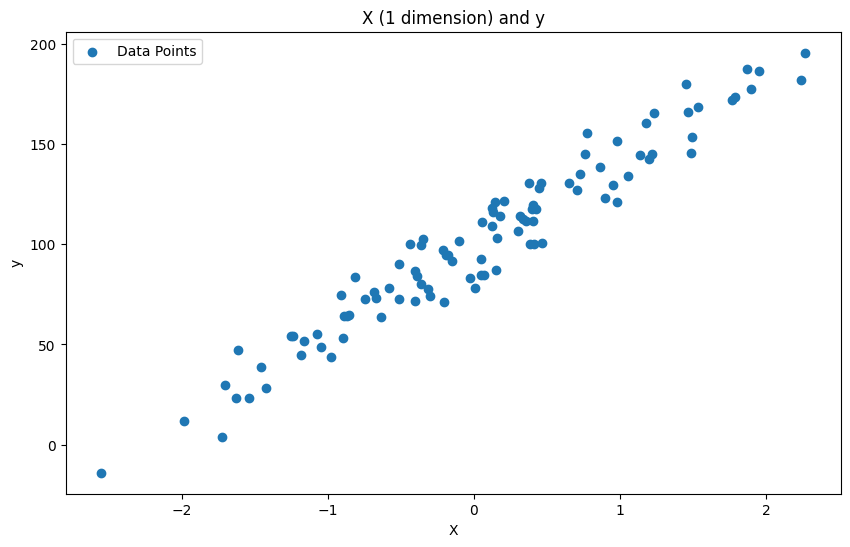

In [3]:

fig, ax = plt.subplots(figsize=(10, 6))


ax.scatter(X, y, label='Data Points')

# X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
# y_pred = reg.predict(X_range)
# ax.plot(X_range, y_pred, color='red', linewidth=2, label= 'regression line')

ax.set_xlabel('X')
ax.set_ylabel('y')
ax.set_title('X (1 dimension) and y')
ax.legend()
plt.show()

In [4]:
def compute_mse(coefs, X, y):
    '''
    coefs is a list that contains a and b: [a,b]
    X is the features set
    y is the target

    Returns a float which is the MSE
    '''
    
    try:
        X = np.array(X)
        y = np.array(y)
        interceptor = coefs[-1]
        y_preds = ((coefs[0] * X)) + interceptor 
        mse = np.mean(np.square(y_preds - y))
    except Exception as e:
        print(e)
        return e
    return mse

. Create a grid of **640000** points that combines a and b with. Check that the grid contains 640000 points.

- a between -200 and 200, step= 0.5
- b between -200 and 200, step= 0.5

This is how to compute the grid with the combination of a and b:

```python
aa, bb = np.mgrid[-200:200:0.5, -200:200:0.5]
grid = np.c_[aa.ravel(), bb.ravel()]
```

In [5]:
aa, bb = np.mgrid[-200:200:0.5, -200:200:0.5]
grid = np.c_[aa.ravel(), bb.ravel()]
grid.shape[0]

640000

4. Compute the MSE for all points in the grid. If possible, parallelize the computations. It may be needed to use `functools.partial` to parallelize a function with many parameters on a list. Put the result in a variable named `losses`.


In [6]:
partial_calculation = partial(compute_mse, X=X.reshape(1,-1)[0], y=y)
losses = np.zeros(grid.shape[0])
for i, coef in zip(range(grid.shape[0]), grid): 
    losses[i] = partial_calculation(coef)

print(losses)

[158315.41493175 158001.96852692 157689.02212209 ...  36930.21718467
  37039.16408205  37148.61097942]


5. Use this chunk of code to plot the MSE in 2D:

```python
aa, bb = np.mgrid[-200:200:.5, -200:200:.5]
grid = np.c_[aa.ravel(), bb.ravel()]
losses_reshaped = np.array(losses).reshape(aa.shape)

f, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(aa,
                    bb,
                    losses_reshaped,
                    100,
                    cmap="RdBu",
                    vmin=0,
                    vmax=160000)
ax_c = f.colorbar(contour)
ax_c.set_label("MSE")

ax.set(aspect="equal",
    xlim=(-200, 200),
    ylim=(-200, 200),
    xlabel="$a$",
    ylabel="$b$")
```

The expected output is:

![ex5q5](./w2_day1_ex5_q5.png)

[None,
 (-200.0, 200.0),
 (-200.0, 200.0),
 Text(0.5, 0, '$a$'),
 Text(0, 0.5, '$b$')]

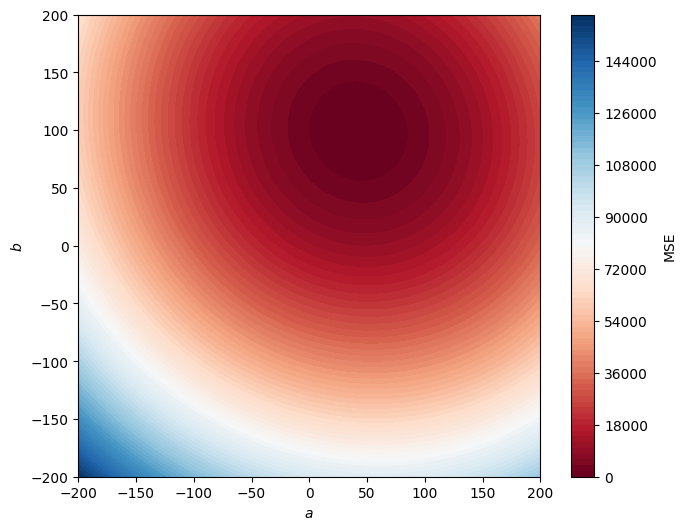

In [7]:
aa, bb = np.mgrid[-200:200:.5, -200:200:.5]
grid = np.c_[aa.ravel(), bb.ravel()]
losses_reshaped = np.array(losses).reshape(aa.shape)

f, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(aa,
                    bb,
                    losses_reshaped,
                    100,
                    cmap="RdBu",
                    vmin=0,
                    vmax=160000)
ax_c = f.colorbar(contour)
ax_c.set_label("MSE")

ax.set(aspect="equal",
    xlim=(-200, 200),
    ylim=(-200, 200),
    xlabel="$a$",
    ylabel="$b$")

6. From the `losses` list, find the optimal value of a and b and plot the line in the scatter point of question 1.

Final Equation: y = 42.5000 * x + 99.0000


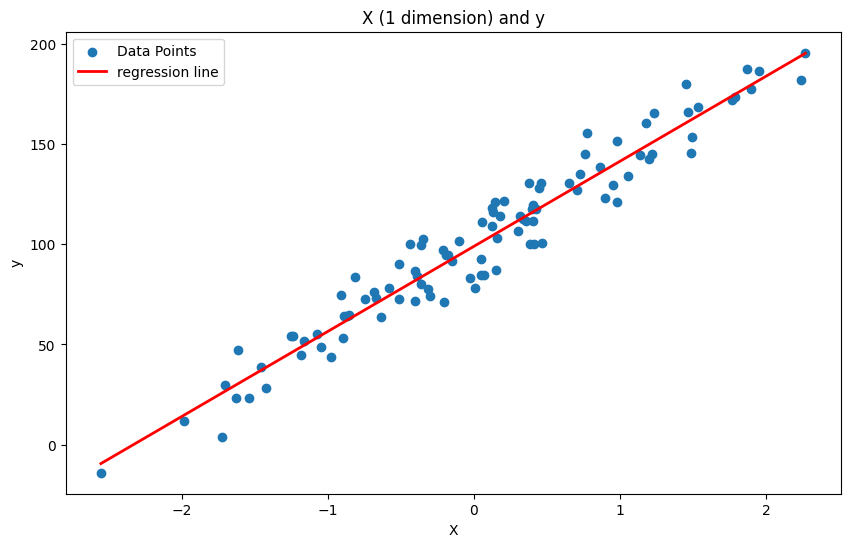

In [16]:
minCoefIndex = np.argmin(losses)
a, b = grid[minCoefIndex][0], grid[minCoefIndex][1]
print(f"Final Equation: y = {a:.4f} * x + {b:.4f}")
fig, ax = plt.subplots(figsize=(10, 6))


ax.scatter(X, y, label='Data Points')

X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_pred = a * (X_range) + b
ax.plot(X_range, y_pred, color='red', linewidth=2, label= 'regression line')

ax.set_xlabel('X')
ax.set_ylabel('y')
ax.set_title('X (1 dimension) and y')
ax.legend()
plt.show()

7. Implement gradient descent to find optimal a and b with `learning rate = 0.1` and `nbr_iterations=100`.

In [9]:
# 1. Initialize parameters
a = 0.0  # initial slope
b = 0.0  # initial intercept
learning_rate = 0.1
nbr_iterations = 100
n = float(len(X)) # number of samples

# Track history for visualization

a_values = []
b_values = []
mse_values = []
# 2. Optimization Loop
for i in range(nbr_iterations):
    # Current prediction
    y_pred = a * X + b
    
    # Calculate gradients (Partial Derivatives)
    # X.T @ (y_pred - y) is a vectorized way to do the summation
    da = (2/n) * np.sum(X * (y_pred - y.reshape(-1, 1)))
    db = (2/n) * np.sum(y_pred - y.reshape(-1, 1))
    
    # Update parameters
    a = a - (learning_rate * da)
    b = b - (learning_rate * db)
    
    # Record progress
    mse = np.mean(np.square(y_pred - y.reshape(-1, 1)))
    a_values.append(a)
    b_values.append(b)
    mse_values.append(mse_values)

print(f"Final Equation: y = {a:.4f} * x + {b:.4f}")

Final Equation: y = 42.6194 * x + 99.1858


8. Save the a and b through the iterations in a two-dimensional numpy array. Add them to the plot of the previous part and observe a and b that converge towards the minimum. The plot should look like this:

![ex5q8](./w2_day1_ex5_q8.png)

[None,
 (-200.0, 200.0),
 (-200.0, 200.0),
 Text(0.5, 0, '$a$'),
 Text(0, 0.5, '$b$')]

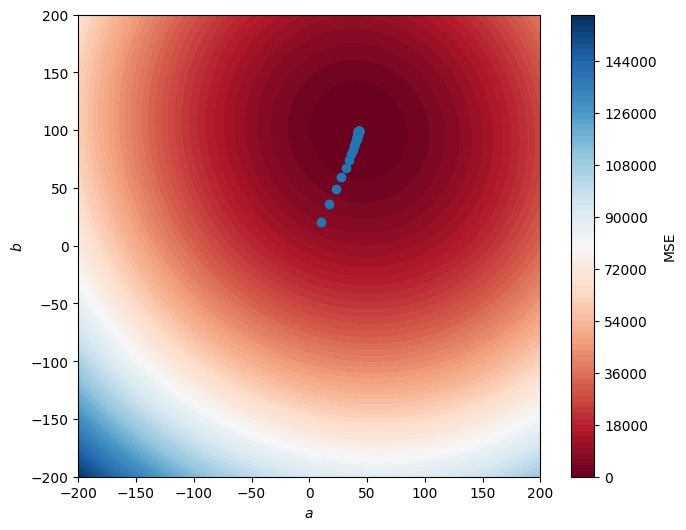

In [10]:
aa, bb = np.mgrid[-200:200:.5, -200:200:.5]
grid = np.c_[aa.ravel(), bb.ravel()]
losses_reshaped = np.array(losses).reshape(aa.shape)

f, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(aa,
                    bb,
                    losses_reshaped,
                    100,
                    cmap="RdBu",
                    vmin=0,
                    vmax=160000,
                    )
ax_c = f.colorbar(contour)
ax_c.set_label("MSE")
ax.scatter(a_values, b_values, label='Data Points')
ax.set(aspect="equal",
    xlim=(-200, 200),
    ylim=(-200, 200),
    xlabel="$a$",
    ylabel="$b$")

9. Use Linear Regression from Scikit-learn. Compare the results.

In [15]:
reg = linear_model.LinearRegression()
reg.fit(X, y)
print(f"Final Equation: y = {reg.coef_[0]:.4f} * x + {reg.intercept_:.4f}")

Final Equation: y = 42.6194 * x + 99.1858
